In [9]:
import numpy as np
from scipy.linalg import eigh
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [10]:
# =========================================================
# 1. Field Operators
# =========================================================


def field_operators(nq, mu):
    Nphi = 2**nq

    delta_phi = np.sqrt(2*np.pi/(Nphi * mu))
    delta_k = np.sqrt(2*np.pi * mu / Nphi)

    # Field values
    alpha = np.arange(Nphi)
    phi_vals = delta_phi * (alpha - (Nphi-1)/2)
    Phi = np.diag(phi_vals)

    # Centered Fourier transform
    

    F = np.fft.fft(np.eye(Nphi)) / np.sqrt(Nphi)
    

    Pi = mu * F @ Phi @ F.conj().T

    return Phi, Pi

In [11]:
# =========================================================
# 2. Local Hamiltonian
# =========================================================
def local_hamiltonian(nq, m2, lam, f, mu=1.0):
    Phi, Pi = field_operators(nq, mu)
    
    H = (
        0.5 * Pi @ Pi
        + 0.5 * m2 * Phi @ Phi
        + lam/24 * np.linalg.matrix_power(Phi, 4)
        + f * Phi
    )
    
    return H

In [12]:
# =========================================================
# 3. Ground State (Exact)
# =========================================================
def ground_state(H):
    vals, vecs = eigh(H)
    return vecs[:, 0]

def reorder_state_center_to_binary(state):
    N = len(state)
    shift = N // 2
    return np.roll(state, -shift)

In [13]:
# =========================================================
# 4. Variational Circuit
# =========================================================
def variational_circuit(nq, layers, params):
    qc = QuantumCircuit(nq)
    p = 0

    for l in range(layers):

        # single-qubit rotations
        for q in range(nq):
            qc.ry(params[p], q)
            qc.rz(params[p+1], q)
            p += 2

        # entanglement layer (skip after last layer)
        if l != layers - 1:
            if l % 2 == 0:
                for q in range(0, nq-1, 2):
                    qc.cz(q, q+1)
            else:
                for q in range(1, nq-1, 2):
                    qc.cz(q, q+1)

    return qc

In [14]:
# =========================================================
# 5. Fidelity Function
# =========================================================
def fidelity(params, nq, layers, target):
    qc = variational_circuit(nq, layers, params)
    psi = Statevector.from_instruction(qc).data
    
    return -np.abs(np.dot(np.conjugate(target), psi))**2

In [15]:
# =========================================================
# 6. Run One Case
def run_case(nq, m2, lam, f, layer_range, mu=1.0, base_restarts=5):
    H = local_hamiltonian(nq, m2, lam, f, mu)
    target = ground_state(H)
    #target = reorder_state_center_to_binary(target)
    
    fidelities = []
    best_params_previous = None  # <-- store best params from previous layer
    
    for layers in layer_range:
        print(f"  Layers = {layers}")
        
        n_params = layers * nq * 2
        
        # increase restarts for small layers (important)
        if layers == min(layer_range):
            n_restarts = 15
        else:
            n_restarts = base_restarts
        
        best_f = 0.0
        best_params_current = None
        
        for r in range(n_restarts):
            
            # Layer-wise initialization
            if best_params_previous is None:
                # first layer → fully random
                x0 = np.random.uniform(0, 2*np.pi, n_params)
            else:
                # extend previous parameters + small noise
                extra = np.random.uniform(0, 2*np.pi, nq * 2)
                x0 = np.concatenate([best_params_previous, extra])
                
                # small noise to avoid traps
                x0 += 0.01 * np.random.randn(n_params)
            
            res = minimize(
                fidelity,
                x0,
                args=(nq, layers, target),
                method='COBYLA',
                options={'maxiter': 10000, 'disp': False}
            )
            
            fid = -res.fun
            
            if fid > best_f:
                best_f = fid
                best_params_current = res.x
        
        fidelities.append(best_f)
        best_params_previous = best_params_current  # <-- carry forward
        
        print(f"    Best Fidelity = {best_f:.6f}")
    
    return fidelities

  Layers = 3
    Best Fidelity = 0.692216
  Layers = 4
    Best Fidelity = 0.998833
  Layers = 5
    Best Fidelity = 0.990086
  Layers = 6
    Best Fidelity = 0.998807
  Layers = 3
    Best Fidelity = 0.500380
  Layers = 4
    Best Fidelity = 0.999812
  Layers = 5
    Best Fidelity = 0.999091
  Layers = 6
    Best Fidelity = 0.999735
  Layers = 3
    Best Fidelity = 0.773860
  Layers = 4
    Best Fidelity = 0.968359
  Layers = 5
    Best Fidelity = 0.992941
  Layers = 6
    Best Fidelity = 0.997352
  Layers = 3
    Best Fidelity = 0.983902
  Layers = 4
    Best Fidelity = 0.999991
  Layers = 5
    Best Fidelity = 0.999989
  Layers = 6
    Best Fidelity = 0.999990
  Layers = 3
    Best Fidelity = 0.996451
  Layers = 4
    Best Fidelity = 0.999911
  Layers = 5
    Best Fidelity = 0.999906
  Layers = 6
    Best Fidelity = 0.999903


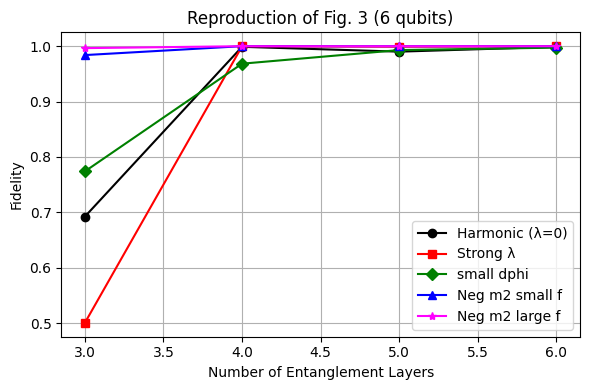

In [16]:
# =========================================================
# 7. Define Physics Cases (Fig. 2 inspired)
# =========================================================
cases = [
    {"label": "Harmonic (λ=0)", "m2": 1.0, "lam": 0.0, "f": 0.0, "mu": 1.0},
    {"label": "Strong λ", "m2": 1.0, "lam": 100.0, "f": 0.0, "mu": 1.0},
    {"label": "small dphi", "m2": 1.0, "lam": 100.0, "f": 0.0, "mu": 4.0},
    {"label": "Neg m2 small f", "m2": -1, "lam": 0.1, "f": 1e-5, "mu": 0.25},
    {"label": "Neg m2 large f", "m2": -1, "lam": 1.0, "f": 4, "mu": 0.25},
]

# =========================================================
# 8. Run Simulation
# =========================================================
nq = 6
layer_range = range(3, 7)   # 3 → 6 layers

results = {}

for case in cases:
   # print("\nRunning case:", case["label"])
    
    fids = run_case(
        nq=nq,
        m2=case["m2"],
        lam=case["lam"],
        f=case["f"],
        mu=case["mu"],
        layer_range=layer_range
    )
    
    results[case["label"]] = fids


# =========================================================
# 9. Plot (Fig. 3 style)
# =========================================================
colors = ['black', 'red', 'green', 'blue', 'magenta']
markers = ['o', 's', 'D', '^', '*']  # closer to paper

plt.figure(figsize=(6,4))

for i, (label, fids) in enumerate(results.items()):
    plt.plot(
        layer_range,
        fids,
        marker=markers[i],
        color=colors[i],
        linestyle='-',
        linewidth=1.5,
        markersize=6,
        label=label
    )

plt.xlabel("Number of Entanglement Layers")
plt.ylabel("Fidelity")
plt.title("Reproduction of Fig. 3 (6 qubits)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()